# Main Cleaning & Feature Engineering

***Round 1 (notebooks 01–02) resolved structural problems in the raw data and produced `games_clean_r1.csv`, 113,065 rows, 35 columns, non-game entries removed. Round 2 EDA (notebook 03) then identified the target variable and the feature shortlist that will enter modelling. This notebook applies those decisions and performs complete feature engineering before exporting final modelling-ready datasets.***

***The target `success_score = log1p(review_count) × wilson_lb` is constructed first, then zero-review games are excluded. Feature transformations follow: `log1p` on `game_age_days`, `Price`, `Achievements`, and `DLC count`; `is_free` derived as a binary flag; `num_tags` carried as-is; and `primary_genre` one-hot encoded against the top 20 genres. The dataset is split temporally (pre-2020 for training, 2020–2023 for testing, 2024 onward as holdout) to prevent leakage. Advanced feature engineering follows: pricing tiers, genre counts, frequency-encoded tags, and VADER description sentiment scores. The three resulting splits are exported to `data/processed/` for modelling.***

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

script_path = Path.cwd()
project_root = script_path.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_cleaning import (
    load_data,
    calculate_success_score,
    filter_zero_reviews,
    transform_features,
    encode_genres,
    split_data,
    add_temporal_features,
    add_pricing_tiers,
    add_genre_count,
    fit_tag_frequencies,
    add_tag_frequency_features,
    add_description_sentiment
)

### Transition to Modular Source Code (`src/`)

With the Exploratory Data Analysis (EDA) phase complete, the data cleaning requirements and feature transformations have stabilized, meaning few (if any) further design changes are expected. 

To prepare for downstream modeling and avoid duplicate code, we transition core preprocessing logic from ad-hoc notebook cells into a modular, production-ready source code directory (`src/`). All preprocessing operations are defined in [`src/data_cleaning.py`](file:///Users/banananakun./Documents/project/Predicting-Video-Game-Commercial-Success-on-Steam/src/data_cleaning.py). This guarantees:
- **Consistency:** The same code handles train, test, and validation splits.
- **Maintainability:** Preprocessing updates can be version-controlled and tested in a single file.
- **Reusability:** Future modeling/inference notebooks can import the pipeline directly.

In [2]:
data_path = project_root / "data" / "processed" / "games_clean_r1.csv"
df = load_data(data_path)

pd.set_option('display.max_columns', None)
df.head(5)

,AppID,Name,Release date,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Header image,Support email,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Min owners,Max owners,Avg owners
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],https://shared.akamai.steamstatic.com/store_it...,support@mangagamer.com,True,False,False,0,0,252,3,0,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],https://shared.akamai.steamstatic.com/store_it...,support@8floor.net,True,True,False,0,0,21,3,0,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],https://shared.akamai.steamstatic.com/store_it...,yujingamesc@gmail.com,True,False,False,0,0,0,0,19,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
3,3631080,Maze Quest VR,2025-04-24,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],https://shared.akamai.steamstatic.com/store_it...,support@realityexpanded.com,True,False,False,0,0,0,0,0,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
4,1654170,Agony VR,2023-04-05,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Turkish']",https://shared.akamai.steamstatic.com/store_it...,office@ignibit.com,True,False,False,0,0,0,0,0,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0


## Target Variable & Zero-Review Filter

***The Wilson confidence interval lower bound is computed here via a vectorized implementation, operating directly on the `Positive` and `Negative` arrays rather than row-wise, avoiding the overhead of `apply`. From this, the target variable `success_score = log1p(Review_Count) × wilson_lb` is constructed.***

***Games with a `Review_Count` of zero are then excluded. With no reviews, the Wilson lower bound collapses to 0.0 and `success_score` is identically zero regardless of any other feature, these entries carry no learnable signal for the target and are dropped before modelling.***

In [3]:
df = calculate_success_score(df)
print("Target variable calculated. Summary statistics:")
print(df[['Positive', 'Negative', 'Review_Count', 'wilson_lb', 'success_score']].describe())

df_filtered = filter_zero_reviews(df)
print(f"\nFiltered out zero-review games. Rows remaining: {len(df_filtered)}")

Target variable calculated. Summary statistics:
           Positive      Negative  Review_Count      wilson_lb  success_score
count  1.130650e+05  1.130650e+05  1.130650e+05  113065.000000  113065.000000
mean   1.121464e+03  1.828297e+02  1.304294e+03       0.391616       1.700395
std    2.913343e+04  5.596425e+03  3.387854e+04       0.327573       2.070077
min    0.000000e+00  0.000000e+00  0.000000e+00       0.000000       0.000000
25%    0.000000e+00  0.000000e+00  0.000000e+00       0.000000       0.000000
50%    7.000000e+00  1.000000e+00  9.000000e+00       0.409275       0.951432
75%    4.400000e+01  1.200000e+01  5.800000e+01       0.689961       2.673162
max    7.642084e+06  1.173003e+06  8.815087e+06       0.994553      13.860372

Filtered out zero-review games. Rows remaining: 81837


**Observation:**
- Filtering out zero-review games drops approximately 31k rows (~28% of the cleaned dataset). This is expected since many Steam releases have minimal traction and do not receive any user reviews.
- The maximum `success_score` of 13.86 is consistent with the top-performing games identified during the final exploratory data analysis (Notebook 3).

## Transform Features

***Transformations follow directly from the feature shortlist established in notebook 03. Features with heavy right skew: `game_age_days`, `Price`, `Achievements`, and `DLC count` receive `log1p` transforms; `is_free` is derived as a binary flag from `Price == 0` rather than folding free-to-play titles into the same continuous distribution as paid games; `num_tags` is carried as-is; and `primary_genre` is extracted as the first entry in the `Genres` string, deferred to the next section for one-hot encoding. All logic is implemented in `src/data_cleaning.py` and called here via `transform_features`.***

| Feature | Transform | Notes |
|---|---|---|
| `success_score` | target variable | `log1p(review_count) × wilson_lb`, defined and justified in notebook 03 |
| `num_tags` | as-is (int) | strongest individual correlation (r ≈ 0.52); proxy for discoverability and tagging effort |
| `game_age_days` | log1p | second strongest correlation (r ≈ 0.41); confirmed confounder, carried as a feature rather than adjusted for in the target |
| `Price` | log1p | right-skewed; weak standalone correlation (r ≈ 0.03); free-to-play flagged separately |
| `is_free` | binary flag | derived from `Price == 0`, free and paid titles likely follow different dynamics |
| `primary_genre` | one-hot (top 20) | first entry in `Genres`; rare genres showed unstable small sample averages and are grouped as `Other` |
| `Achievements` | log1p | weak standalone correlation (r ≈ 0.08), but median score shifted meaningfully across achievement tiers in EDA |
| `DLC count` | log1p | weakest correlation (r ≈ 0.06); no visible trend in scatter, but right-skewed distribution still warrants the transform |

In [4]:
df_transformed = transform_features(df_filtered, snapshot_date='2026-01-05')
print(f"Features transformed. Final shape: {df_transformed.shape}")
print(df_transformed[['game_age_days', 'log_game_age_days', 'log_price', 'is_free', 'num_tags', 'primary_genre', 'log_achievements', 'log_dlc_count']].head())

Features transformed. Final shape: (81837, 46)
   game_age_days  log_game_age_days  log_price  is_free  num_tags  \
0           3447           8.145550   1.830980        0         4   
1           2436           7.798523   1.790091        0        16   
5            272           5.609472   3.610648        0        18   
7           1704           7.441320   0.688135        0        12   
8           1484           7.303170   0.463734        0         7   

  primary_genre  log_achievements  log_dlc_count  
0     Adventure          0.000000       0.000000  
1        Casual          0.000000       0.000000  
5    Simulation          0.000000       0.693147  
7        Casual          2.302585       0.000000  
8        Action          4.615121       0.693147  


## Temporal Split

***The dataset is divided into three non-overlapping splits by release year. Games released before 2020 form the training set; 2020–2023 form the test set; 2024 onward serve as an out-of-time validation holdout. This ordering ensures no future release information leaks into the training distribution, a random split would allow the model to learn from games it would never have observed at the point of prediction. The 2024+ cohort is held out entirely until final evaluation and is not used for any model selection or hyperparameter decisions.***

***As noted in notebook 03, older games carry a structural advantage in `success_score` through time-on-market alone. `game_age_days` is included as a feature to give the model visibility into this effect, though it cannot fully resolve it, a 2010 release and a 2022 release remain not directly comparable on `success_score` alone. This is acknowledged as a known limitation of the project.***

In [5]:
train_df, test_df, val_df = split_data(df_transformed)
print(f"Train set shape: {train_df.shape} (releases before 2020)")
print(f"Test set shape: {test_df.shape} (releases from 2020 to 2023)")
print(f"Validation set shape: {val_df.shape} (releases from 2024 onward)")

Train set shape: (29128, 46) (releases before 2020)
Test set shape: (34531, 46) (releases from 2020 to 2023)
Validation set shape: (18178, 46) (releases from 2024 onward)


## One-Hot Encode Genres

***`primary_genre` is one-hot encoded against the top 20 genres by frequency but that frequency is determined from the training set only. Fitting the genre vocabulary on the full dataset before splitting would allow test and validation distributions to influence which genres are retained, constituting a form of leakage. Genres absent from the top 20 training list are mapped to `Other` in the test and validation sets, and any dummy columns present in those sets but absent from training are dropped to guarantee consistent feature shapes across all three splits.***

In [6]:
train_df, top_genres = encode_genres(train_df, top_n=20)
test_df, _ = encode_genres(test_df, top_genres=top_genres)
val_df, _ = encode_genres(val_df, top_genres=top_genres)

print(f"Top 20 Genres determined from Train set: {top_genres}")
print(f"Train set columns after genre encoding: {train_df.shape[1]}")
print(f"Test set columns after genre encoding: {test_df.shape[1]}")
print(f"Validation set columns after genre encoding: {val_df.shape[1]}")

Top 20 Genres determined from Train set: ['Action', 'Adventure', 'Casual', 'Indie', 'Simulation', 'Strategy', 'RPG', 'Violent', 'Free To Play', 'Racing', 'Sexual Content', 'Sports', 'Education', 'Massively Multiplayer', 'Nudity', 'Unknown', 'Gore', 'Utilities', 'Early Access', 'Design & Illustration']
Train set columns after genre encoding: 67
Test set columns after genre encoding: 67
Validation set columns after genre encoding: 67


# Advanced Feature Engineering

***In this section, we extract macro-level launch characteristics. To prevent any data leakage, any data-derived features (such as tag counts) are fitted exclusively on the training split before being applied to the test and validation sets.***

### Temporal: Release Year
***We extract `release_year` from the release date. This serves to capture macro-level changes in market volume and competition trends over time.***

In [7]:
print("Engineering release_year temporal feature")
train_df = add_temporal_features(train_df)
test_df = add_temporal_features(test_df)
val_df = add_temporal_features(val_df)

Engineering release_year temporal feature


### Pricing Tiers
***We group game pricing into four distinct tiers: `free` ($0.00), `budget` ($0.01 to $5.00), `mid` ($5.01 to $20.00), and `premium` (>$20.00). These are one-hot encoded using a categorical definition to guarantee matching columns in all splits.***

In [8]:
print("Engineering pricing tier dummy columns")
train_df = add_pricing_tiers(train_df)
test_df = add_pricing_tiers(test_df)
val_df = add_pricing_tiers(val_df)

Engineering pricing tier dummy columns


### Genre Structure: Genre Count
***We calculate the number of genres a game belongs to (`num_genres`). This represents the game's cross-genre positioning.***

In [9]:
print("Engineering genre count features")
train_df = add_genre_count(train_df)
test_df = add_genre_count(test_df)
val_df = add_genre_count(val_df)

Engineering genre count features


### Tag Structure: Frequency-Encoded Tag Aggregates
***We fit tag frequency statistics using ONLY the training split. Each game's tags are then mapped to these frequencies to generate statistical indicators (`tag_freq_mean`, `tag_freq_max`, `tag_freq_min`, `tag_freq_sum`), telling the models if a game targets crowded vs. niche markets.***

In [10]:
print("Fitting training set tag frequencies & generating aggregate features")
tag_freq_map = fit_tag_frequencies(train_df)
train_df = add_tag_frequency_features(train_df, tag_freq_map)
test_df = add_tag_frequency_features(test_df, tag_freq_map)
val_df = add_tag_frequency_features(val_df, tag_freq_map)

Fitting training set tag frequencies & generating aggregate features


### Description Text: VADER Sentiment Scores
***We perform NLP sentiment analysis on the textual `About the game` column. We compute the VADER compound score for each game, serving as a proxy for description appeal and copywriting tone.***

In [11]:
print("Computing VADER description sentiment score")
train_df = add_description_sentiment(train_df)
test_df = add_description_sentiment(test_df)
val_df = add_description_sentiment(val_df)

Computing VADER description sentiment score


### Verification of Shapes
***Print final shapes to check feature dimensions before running tests.***

In [12]:
print(f"Final Train shape: {train_df.shape}")
print(f"Final Test shape: {test_df.shape}")
print(f"Final Validation shape: {val_df.shape}")

Final Train shape: (29128, 79)
Final Test shape: (34531, 79)
Final Validation shape: (18178, 79)


## Feature Engineering Visualizations

***We generate two validation plots to inspect the newly engineered features:***
1. ***Temporal Split Distribution: A bar chart of release year color-coded by split assignment.***
2. ***Success Score Density Plot: A Kernel Density Estimate (KDE) plot of target success_score across splits to verify structural consistency.***

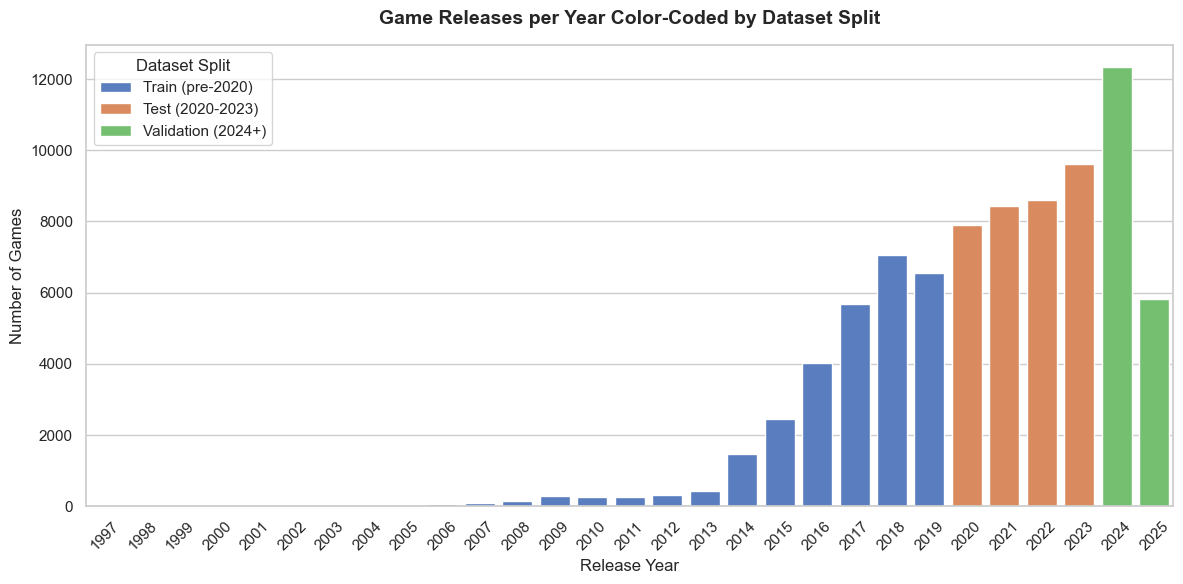

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = pd.concat([
    train_df[['release_year']].assign(Split='Train (pre-2020)'),
    test_df[['release_year']].assign(Split='Test (2020-2023)'),
    val_df[['release_year']].assign(Split='Validation (2024+)')
])

year_counts = plot_data.groupby(['release_year', 'Split']).size().reset_index(name='Game Count')

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=year_counts, x='release_year', y='Game Count', hue='Split', dodge=False, palette='muted')

plt.title('Game Releases per Year Color-Coded by Dataset Split', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Dataset Split', frameon=True)
plt.tight_layout()
plt.show()

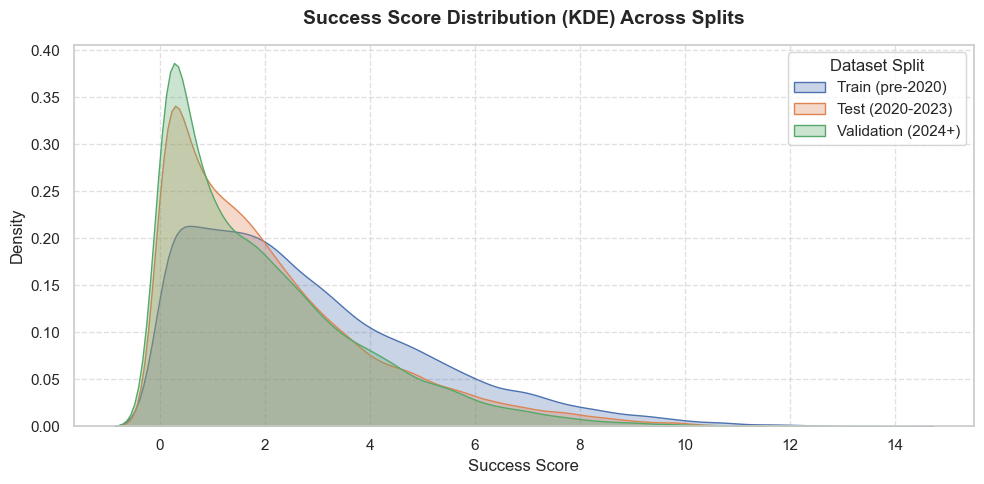

In [14]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train_df, x='success_score', label='Train (pre-2020)', fill=True, alpha=0.3)
sns.kdeplot(data=test_df, x='success_score', label='Test (2020-2023)', fill=True, alpha=0.3)
sns.kdeplot(data=val_df, x='success_score', label='Validation (2024+)', fill=True, alpha=0.3)
plt.title('Success Score Distribution (KDE) Across Splits', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Success Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Dataset Split', frameon=True)
plt.tight_layout()
plt.show()

***Before proceeding to model training, these visualizations confirm the integrity of our temporal splits and highlight the structural biases inherent in the data.***

***Key Observations:***

* ***Explosive Platform Growth:*** **The bar chart illustrates a massive exponential increase in Steam game releases over time. The annual volume in the test set (2020–2023) dwarfs earlier years. This reinforces exactly why a temporal split is mandatory, a randomized split would leak dense, highly competitive future market conditions into the past training data.**
* ***Strict Temporal Boundaries:*** **The color coding perfectly validates our splitting logic. There is zero overlap between the Train (blue), Test (orange), and Validation (green) cohorts.**
* ***Time-on-Market Advantage:*** **The KDE plot demonstrates how game age impacts our target variable. While all three distributions are heavily right-skewed (most games cluster near a low success score), the Train set has a visibly thicker tail and a less extreme peak near zero compared to the newer splits. Older games have a structural advantage simply because they have had more years to accumulate the user reviews that drive the `success_score`.**
* ***The Necessity of Age as a Feature:*** **The leftward shift of the `success_score` in newer cohorts perfectly validates our decision to include `game_age_days` in the feature shortlist. The model requires this temporal context to accurately scale and interpret the success of a 2023 release versus a 2015 release.**

## Sanity Checks

***Four assertions verify the pipeline before export. Row counts across all three splits must sum to `df_filtered` exactly, any mismatch would indicate rows lost or duplicated during the temporal split. All splits must have identical column counts and column names alignment, confirming that `encode_genres` and `add_pricing_tiers` aligned the dummy columns to the training vocabulary correctly. `success_score` must be non-negative across every split. Finally, there must be no NaN values present in the newly engineered feature columns.***

In [15]:
# Row counts check
assert len(train_df) + len(test_df) + len(val_df) == len(df_filtered), "Row count mismatch after split"

# Column count and name alignment check
assert train_df.shape[1] == test_df.shape[1] == val_df.shape[1], \
    f"Column mismatch: train={train_df.shape[1]}, test={test_df.shape[1]}, val={val_df.shape[1]}"
assert (train_df.columns == test_df.columns).all(), "Train and Test columns do not align"
assert (train_df.columns == val_df.columns).all(), "Train and Validation columns do not align"

# Target value checks
assert (train_df['success_score'] >= 0).all()
assert (test_df['success_score'] >= 0).all()
assert (val_df['success_score'] >= 0).all()

# NaN verification in engineered features
new_cols = [
    'release_year', 'price_tier_free', 'price_tier_budget', 'price_tier_mid', 'price_tier_premium',
    'num_genres', 'tag_freq_mean', 'tag_freq_max', 'tag_freq_min', 'tag_freq_sum', 'desc_sentiment_score'
]
assert not train_df[new_cols].isnull().any().any(), "NaNs found in training features"
assert not test_df[new_cols].isnull().any().any(), "NaNs found in test features"
assert not val_df[new_cols].isnull().any().any(), "NaNs found in validation features"

print(f"Sanity check passed. {len(train_df)} / {len(test_df)} / {len(val_df)} rows across train/test/val.")
print(f"Perfect feature alignment verified: All splits have {train_df.shape[1]} columns.")

Sanity check passed. 29128 / 34531 / 18178 rows across train/test/val.
Perfect feature alignment verified: All splits have 79 columns.


## Export

***With the target variable constructed, zero-review entries removed, features transformed, the temporal split applied, genres encoded, and advanced feature extraction completed, the three final modelling-ready splits are exported to `data/processed/` as `games_train.csv`, `games_test.csv`, and `games_val.csv`.***

In [16]:
train_out = project_root / "data" / "processed" / "games_train.csv"
test_out = project_root / "data" / "processed" / "games_test.csv"
val_out = project_root / "data" / "processed" / "games_val.csv"

train_df.to_csv(train_out, index=False)
test_df.to_csv(test_out, index=False)
val_df.to_csv(val_out, index=False)

print(f"Saved Train set with features to {train_out}")
print(f"Saved Test set with features to {test_out}")
print(f"Saved Validation set with features to {val_out}")

Saved Train set with features to /Users/banananakun./Documents/project/Predicting-Video-Game-Commercial-Success-on-Steam/data/processed/games_train.csv
Saved Test set with features to /Users/banananakun./Documents/project/Predicting-Video-Game-Commercial-Success-on-Steam/data/processed/games_test.csv
Saved Validation set with features to /Users/banananakun./Documents/project/Predicting-Video-Game-Commercial-Success-on-Steam/data/processed/games_val.csv
